In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


class CMGDPro(optim.Optimizer):
    def __init__(self,
                 params,
                 lr,
                 alpha_reduce,
                 alpha_increase,
                 beta,
                 boundary=0.5,
                 lr_max=10,
                 lr_min=1e-5,
                 weight_decay=0
                 ) -> None:
        if lr <= 0.0:
            raise ValueError('Invalid learning rate: {}'.format(lr))
        if weight_decay < 0.0:
            raise ValueError('Invalid weight_decay value: {}'.format(weight_decay))
        if alpha_reduce < 0.0 or alpha_reduce > 1.0:
            raise ValueError('Invalid alpha value: {}'.format(alpha_reduce))
        if alpha_increase < 0.0:
            raise ValueError('Invalid alpha value: {}'.format(alpha_increase))
        if beta < 0.0:
            raise ValueError('Invalid beta value: {}'.format(beta))
        if lr_min < 0 or lr_max < 0:
            raise ValueError('Invalid learning rate range: {}-{}'.format(lr_min, lr_max))
        if lr_min > lr_max:
            raise ValueError('Invalid learning rate order: {}>{}'.format(lr_min, lr_max))
        if boundary <= 0:
            raise ValueError('Invalid boundary value: {}'.format(boundary))

        defaults = dict(
            lr=lr,
            alpha_reduce=alpha_reduce,
            alpha_increase=alpha_increase,
            beta=beta,
            boundary=boundary,
            lr_max=lr_max,
            lr_min=lr_min,
            weight_decay=weight_decay
        )
        super().__init__(params, defaults)

    def step(self, closure=None):
        """
        第一次参数更新: 仅保留梯度数据，不更改学习率
        :param closure:
        :return:
        """
        loss = None
        if closure is not None:
            loss = closure()  # 第一次前向传播与反向传播

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError(
                        'MGD does not support sparse gradients, '
                        'please consider SparseAdam instead'
                    )

                state = self.state[p]

                # 初始化历史梯度信息(每次调用次方法时，都将获得初始化的历史梯度，以避免小批量时的冲突问题)
                if len(state) == 0:
                    state['grad_hist'] = nn.init.constant_(
                        torch.empty_like(
                            p.data, memory_format=torch.preserve_format
                        ), 0
                    )
                    state['lr'] = nn.init.constant_(
                        torch.empty_like(
                            p.data, memory_format=torch.preserve_format
                        ), group['lr']
                    )

                # 第一次状态参数更新
                if group['weight_decay'] != 0:
                    grad = grad.add(p.data, alpha=group['weight_decay'])

                state['grad_hist'] = grad

                # 执行梯度下降
                # 计算权重变化量
                weight_change = -state['lr'] * grad
                # # 计算截断阈值增益
                # clamped_gain = torch.abs(p.data).mean() / torch.abs(p.data)
                # 计算截断阈值
                threshold = group['boundary'] * torch.abs(p.data).mean()
                # 使用 clamp 函数进行截断
                clamped_weight_change = torch.clamp(weight_change, -threshold, threshold)
                # print(f"p:{p.data}")
                # print(f"grad:{grad}")
                # print(f"clamped_weight_change:{clamped_weight_change}")
                # 权重更新
                p.data.add_(clamped_weight_change)
                # 更新学习率
                mask = (clamped_weight_change != weight_change)  # mask中true的部分代表被截断的部分
                new_lr = torch.where(mask, torch.abs(clamped_weight_change / grad), state['lr'])  # 当mask对应部分为true(被截断)，则使用调整后的学习率，否则使用原学习率
                state['lr'] = new_lr

        return loss

    def step_follow(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()  # 第二次前向传播与反向传播

        for group in self.param_groups:
            ######################
            # # 计算全局的学习率梯度缩放比
            # scale_rate = None
            # lr_gradients = []
            # for p in group['params']:
            #     state = self.state[p]
            #     if len(state) == 0:  # 如果没有初始化变量则没有学习率梯度，直接的缩放比为1
            #         scale_rate = 1
            #         break
            #     lr_grad = - state['grad_hist'] * torch.abs(p.grad)
            #     lr_gradients.append(lr_grad.view(-1))
            # if scale_rate is None:
            #     all_gradients = torch.cat(lr_gradients)
            #     epsilon = 1e-20
            #     scale_rate = 1 / (torch.abs(all_gradients).mean() + epsilon)
            # print(1 / scale_rate)
            ######################
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError(
                        'MGD does not support sparse gradients, '
                        'please consider SparseAdam instead'
                    )

                state = self.state[p]

                if len(state) == 0:  # 如果没有初始化变量则先初始化
                    state['grad_hist'] = nn.init.constant_(
                        torch.empty_like(
                            p.data, memory_format=torch.preserve_format
                        ), 0
                    )
                    state['lr'] = nn.init.constant_(
                        torch.empty_like(
                            p.data, memory_format=torch.preserve_format
                        ), group['lr']
                    )

                if group['weight_decay'] != 0:  # 计算考虑了weight_decay后的梯度
                    grad = grad.add(p.data, alpha=group['weight_decay'])

                # 计算学习率的梯度
                lr_grad = - state['grad_hist'] * grad
                lr_grad = torch.sqrt(torch.abs(lr_grad)) * torch.sign(lr_grad)
                # print(lr_grad)
                # # 拉伸学习率的梯度
                # epsilon = 1e-20
                # scale_rate = 1 / (torch.max(lr_grad) - torch.min(lr_grad) + epsilon)
                # lr_grad *= scale_rate
                # print(f"lr_grad:{lr_grad}")
                # print(f"lr_grad_sqrt:{torch.abs(lr_grad)**0.5}")
                # print(f"lr_grad_ln:{torch.log(torch.abs(lr_grad))}")

                # 更新历史梯度记录
                state['grad_hist'] = grad

                # 更新学习率
                alpha_reduce = group['alpha_reduce']
                alpha_increase = group['alpha_increase']
                beta = group['beta']
                compromise = torch.tanh(beta * lr_grad)
                lr_gain = 1 - (alpha_reduce * (compromise > 0).float() + alpha_increase * (
                        compromise <= 0).float()) * compromise
                state['lr'].data = state['lr'].data * lr_gain
                state['lr'].data = torch.clamp(state['lr'].data, min=group['lr_min'], max=group['lr_max'])

                # 执行梯度下降
                # 计算权重变化量
                weight_change = -state['lr'] * grad
                # 计算截断阈值
                threshold = group['boundary'] * torch.abs(p.data).mean()
                # 使用 clamp 函数进行截断
                clamped_weight_change = torch.clamp(weight_change, -threshold, threshold)
                # print(f"p:{p.data}")
                # print(f"grad:{grad}")
                # print(f"clamped_weight_change:{clamped_weight_change}")
                # 权重更新
                p.data.add_(clamped_weight_change)
                # 更新学习率
                mask = (clamped_weight_change != weight_change)  # mask中true的部分代表被截断的部分
                new_lr = torch.where(mask, torch.abs(clamped_weight_change / grad), state['lr'])  # 当mask对应部分为true(被截断)，则使用调整后的学习率，否则使用原学习率
                state['lr'] = new_lr

        return loss

In [26]:
import inspect
import torch
import torch.nn as nn
import torch.optim as optim
from Common.Core.Universal.NNFrameWork import NNFrameWork, cpu, gpu
from Common.Core.CustomLayers.Activations.Relpu import RelpuGlob
from d2l import torch as d2l
import matplotlib.pyplot as plt

In [53]:
class LaplaceActivation(nn.Module):
    """
    Laplace激活函数(sin指数衰减激活函数)
    """

    def __init__(self, features):
        super().__init__()
        self.a = nn.Parameter(torch.ones(features))

    def forward(self, x):
        view_shape = [1] * x.dim()
        view_shape[1] = -1

        a = self.a.view(view_shape)

        return torch.exp(-torch.abs(a * x)) * torch.sin(x)


class SingleHiddenLayer1d(nn.Module):
    """
    单隐层增量神经网络单元
    """

    def __init__(self, input_size, hidden_size, output_size, activation1, activation2):
        super().__init__()
        self.hidden_size = hidden_size
        self.bn_in = nn.BatchNorm1d(input_size)
        self.bn_in.bias.data = torch.randn_like(self.bn_in.bias.data)

        #################################激活函数设置1################################
        if isinstance(activation1(), RelpuGlob):
            self.a_in = activation1(input_size, u_a=-0.5, u_b=2.0)
        elif 'features' in inspect.signature(activation1).parameters:
            self.a_in = activation1()
        else:
            self.a_in = activation1()
        #################################激活函数设置1################################

        self.linear1 = nn.Linear(input_size, hidden_size, bias=False)
        self.bn_out = nn.BatchNorm1d(hidden_size)
        self.bn_out.bias.data = torch.randn_like(self.bn_out.bias.data)

        #################################激活函数设置2################################
        if isinstance(activation2(), RelpuGlob):
            self.a_out = activation2(hidden_size, u_a=-0.5, u_b=2.0)
        elif 'features' in inspect.signature(activation2).parameters:
            self.a_out = activation2(hidden_size)
        else:
            self.a_out = activation2()
        #################################激活函数设置2################################

        self.dropout = nn.Dropout(0.5)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x_in = x
        x = self.bn_in(x)
        x = self.a_in(x)
        x = self.linear1(x)
        mid_out = x
        x = self.bn_out(x)
        x = self.dropout(self.a_out(x))
        x = self.linear2(x)
        return x, torch.cat([x_in, mid_out], dim=1)


class DynaSInit(nn.Module):
    """
    增量神经网络初始化单元
    """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size, bias=False)
        self.linear2 = nn.Linear(hidden_size, output_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.bn.bias.data = torch.randn_like(self.bn.bias.data)
        self.activation = nn.ReLU()

    def forward(self, x):
        middle = self.linear1(x)
        output = self.linear2(self.activation(self.bn(middle)))
        return output, torch.cat([x, middle], dim=1)


class DynamicNN1d(NNFrameWork):
    """
    动态神经网络总体架构v1
    """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.layers = nn.ModuleList()
        self.layers.append(DynaSInit(input_size, hidden_size, output_size))
        self.bandwidth = hidden_size + output_size

    def forward(self, x):
        output = 0
        for layer in self.layers:
            x, hidden_out = layer(x)
            output += x
            x = hidden_out
        return output

    def add_layer(self, hidden_size, activation1, activation2):
        self.layers.append(SingleHiddenLayer1d(self.bandwidth, hidden_size, self.output_size, activation1, activation2))
        self.bandwidth += hidden_size
        self.to(self.device)

    def delete_layer(self, key):
        self.layers.pop(key)
        self.bandwidth -= self.layers[-1].hidden_size

    def set_step_optimizer(self):
        self.optimizer = CMGDPro(self.layers[-1].parameters(), lr=1, alpha_reduce=0.99, alpha_increase=0.99, beta=2e2, boundary=0.5, lr_min=1e-5, lr_max=100)
        # self.optimizer = optim.Adam(self.layers[-1].parameters(), lr=0.1,)
            # self.optimizer = optim.SGD(self.parameters(), lr=lr, momentum=momentum)



def plot_fitting_result(net, x, y):
    """
    用于显示模型的拟合结果
    :param net:
    :param x:
    :param y:
    :return:
    """
    net.set_device(cpu())
    d2l.use_svg_display()
    plt.figure(figsize=(5, 5))
    plt.plot(x.detach().numpy(), y.detach().numpy(), label="ground truth")
    plt.plot(x.detach().numpy(), net.predict(x).to("cpu").detach().numpy(), label="prediction")
    plt.legend()
    plt.show()


def dyna_train(net, a1, a2, hidden_size, data_iter, lr, epochs, x_to_fit, y_to_fit):
    """
    动态训练神经网络
    :param net: 网络
    :param a1: 激活函数1
    :param a2: 激活函数2
    :param hidden_size: 隐藏层数量
    :param data_iter: 数据迭代器
    :param lr: 学习率
    :param epochs: 训练轮数
    :param x_to_fit: 拟合数据x
    :param y_to_fit: 拟合数据y
    :return:
    """
    net.add_layer(hidden_size, a1, a2)
    net.set_step_optimizer()
    net.train_fixed(data_iter, epochs=epochs, plot_hist=True)
    plot_fitting_result(net, x_to_fit, y_to_fit)
    return net.loss_history[-1]

# 表现不佳的原因：没有使用step_follow的学习率更新方法

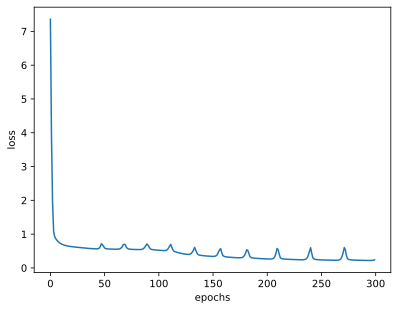

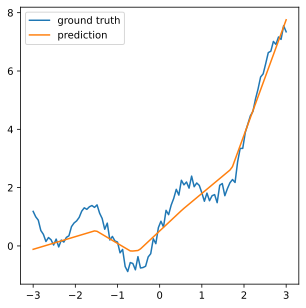

In [54]:
import torch.utils.data as Data

# 生成非线性数据
x = torch.linspace(-3, 3, 100).reshape(-1, 1)
noise = torch.randn(*x.shape)
x_outer = torch.linspace(-6, 6, 1000).reshape(-1, 1)
y = (4.2 * (x + 1) ** 2 + 1.1 + noise + 1 * torch.randn(*x.shape) + 10 * torch.sin(x * 3)) * 1e-1
y_outer = 4.2 * (x_outer + 1) ** 2 + 1.1 + 1 * torch.randn(*x_outer.shape) + 10 * torch.sin(x_outer * 15)
dataSet = Data.TensorDataset(x, y)
data_iter = Data.DataLoader(dataSet, batch_size=100, shuffle=True)

# 初始化动态神经网络
dyna_nn = DynamicNN1d(1, 10, 1)
dyna_nn.set_step_optimizer()
dyna_nn.set_criterion(nn.MSELoss())
dyna_nn.set_device(gpu())

# 动态神经网络初始化单元训练
dyna_nn.train_fixed(data_iter, epochs=300, plot_hist=True)
plot_fitting_result(dyna_nn, x, y)

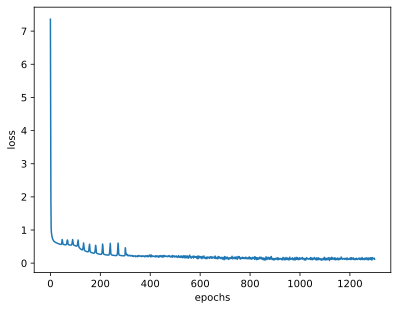

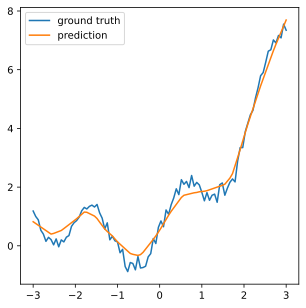

0.11771426349878311

In [55]:
# 动态神经网络第一次训练
dyna_train(dyna_nn, nn.ReLU, nn.ReLU, 10, data_iter, 0.01, 1000, x, y)

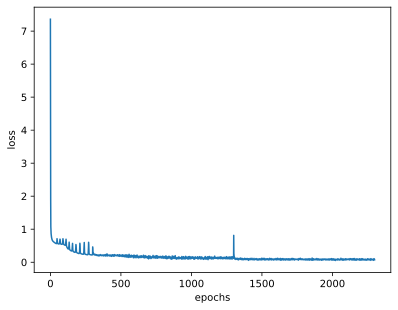

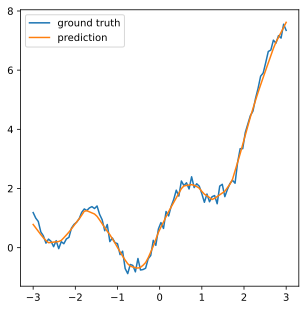

0.07387992739677429

In [56]:
# 动态神经网络第二次训练
dyna_train(dyna_nn, nn.ReLU, nn.ReLU, 20, data_iter, 0.01, 1000, x, y)

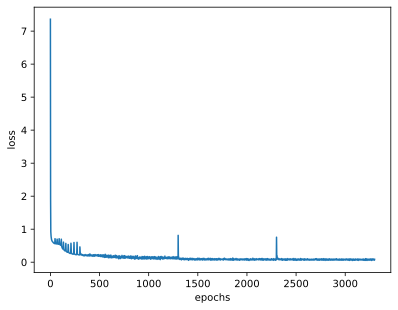

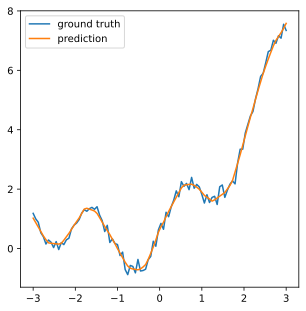

0.08842848986387253

In [57]:
# 动态神经网络第三次训练
dyna_train(dyna_nn, nn.ReLU, nn.ReLU, 30, data_iter, 0.01, 1000, x, y)

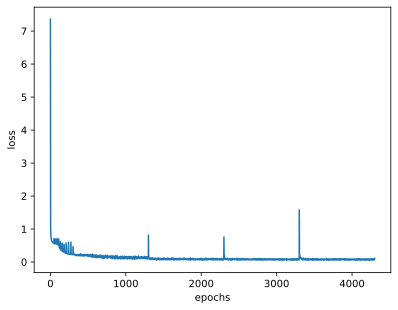

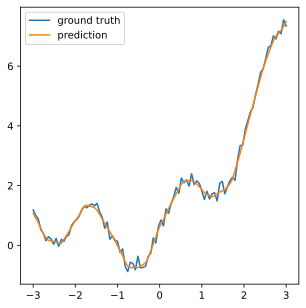

0.10659036040306091

In [58]:
# 动态神经网络第三次训练
dyna_train(dyna_nn, nn.ReLU, nn.ReLU, 40, data_iter, 0.01, 1000, x, y)

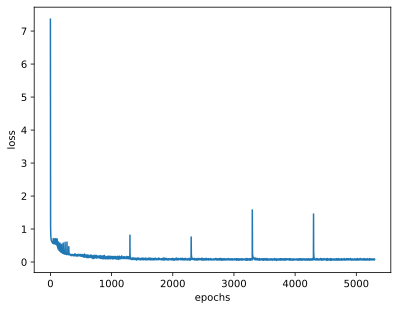

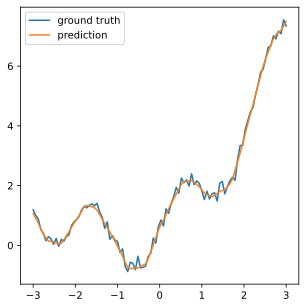

0.07310479134321213

In [59]:
# 动态神经网络第三次训练
dyna_train(dyna_nn, nn.ReLU, nn.ReLU, 40, data_iter, 0.01, 1000, x, y)

In [ ]:
# 表现不佳的原因：没有使用step_follow